In [1]:
#%pip install -r requirements.txt --upgrade

In [3]:
%reload_ext autoreload
%autoreload 2

import os
import warnings
from typing import Dict, List, Tuple, Union

import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import scipy
import seaborn as sns
from rewardgym import agents, get_configs, get_env
from rewardgym.runner import pspy_run_task
from rewardgym.psychopy_render.logger import SimulationLogger
from rewardgym.utils import check_seed
from tqdm.auto import tqdm
from joblib import Parallel, delayed


pd.set_option("future.no_silent_downcasting", True)

plt.rcParams.update({"text.usetex": True, "font.family": "Helvetica"})
plot_format = ".pdf"
sns.set_context("paper", font_scale=1.2)

# Setting up the Learners

Because of the graph structure at the basis of each task, we can formalize a single model, that tests multiple computational theories. The framework provides the agent with an observation ($s_t$), which is used by the agent to sample an action ($a_t$), for which the agent receives the next observation ($s_{t+1}$) and a reward ($r_t$), where $t$ indicates the current step within a trial (or episode). To solve the two-step task, we use an off-policy implementation (Economides et al., 2015) of a hybrid agent that encompasses both model-free and model-based reinforcement learning strategies(Gläscher et al. 2010) and is typically used for this task (Daw et al. 2011). We augment the hybrid agent, with two learning rates for positive and negative reward prediction errors, which have a distinct influence on risk-taking behavior in the risk-sensitive task (Niv et al. 2012).

**Model-free learner:**
The model-free learner is a classic Q-learning agent with eligibility traces (Economides et al., 2015). We represent the different $Q$ values as a $n_{\text{states}} \times n_{\text{actions}}$ matrix, where the eligibility traces $e$ have the same dimensions. In each step, we update the eligibility traces by the visited state action pair:

$$e(s_t,a_t) = e(s_t, a_t)  + 1$$

Then the reward prediction error ($\delta_{rpe})$ is calculated using a TD-learning rule:
$$
\delta_{\text{rpe}} = 
\begin{cases}r_t - Q(s_t, a_t), & \text{if } s_t \text{ is terminal}\\
r_t + \gamma * \max_{a} Q(s_{t+1}, a) - Q(s_t, a_t), & \text{else}
\end{cases}
$$
The model-free Q-values ($Q_{MF}$) are then updated with the eligibility traces:
$$
    Q_{MF}= 
\begin{cases}
    Q_{MF} + \alpha^+ *\delta_{\text{rpe}} * e,& \text{if } \delta_{\text{rpe}}> 0\\
    Q_{MF} + \alpha^- *\delta_{\text{rpe}} * e,& \text{if } \delta_{\text{rpe}}\leq 0\\
\end{cases}
$$
In the final step, decay is applied to the eligibility traces:
$$e(s, a) = \lambda * \gamma*e$$ 
As is commonly done, the eligibility traces are reset to 0 at the end of each trial (Economides et al., 2015).

**Model-based learner:**
The model-based part of the model learns the state transition matrix $T$, with dimensions $n_{\text{states}} \times n_{\text{actions}} \times n_{\text{states}}$ using the state prediction error, as implemented in \cite{glascherStatesRewardsDissociable2010}:

$$\delta_{\text{spe}} = 1 - T(s_t, a_t, s_{t+1})$$

This is updated at each step:

$$T(s_t,a_t, s_{t+1}) = T(s_t, a_t, s_{t+1}) + \eta * \delta_{spe}$$
To keep $T$ in the range $0$ to $1$, the other transitions are multiplied by $1 - \eta$
$$
T(s_t, a_t, s_{t+1}') = T(s_t, a_t, s_{t+1}') * (1-\eta), \text{ where } s_{t+1}'\neq s_{t+1}
$$

After each update of $T$ and $Q_{MF}$, all $Q_{MB}$ are updated as well. For each state $s$ that is not terminal, the updating of $Q_{MB}$ uses the below rule:
$$Q_{MB}(s_t, a_t) = T(s_t, a_t, s_{t+1}) * \max_{a} Q_{MF}(s_t, a_t),$$ for terminal $s$, $Q_{MB}$ and $Q_{MF}$ are identical: $Q_{MB}(s, a)=Q_{MF}(s, a)$.

Finally, we combine model-free and model-based $Q$ values using the weighting parameter $w$:

$$Q_{HYB} = w * Q_{MB}(s,a) + (1 - w) * Q_{MF}(s,a)$$

Actions by the agent are sampled using a softmax decision rule, with the inverse temperature $\beta$. To accompany task designs, such as the one used in the risk-sensitive task, we calculate the probabilities, only based on the actions that are available in the current step:
$$Q_{\text{avail}} = Q[s, a \in A_{avail}]$$

$$P(s, a) = \frac{\exp (Q_{avail}(s, a) * \beta)}{\sum_{b=1}^n\exp (Q_{avail}(s, b) * \beta)} $$

While these computations are formally employed by the agent, we implemented a commonly used short-cut, assuming that the agent has full knowledge about the transition probabilities ($T$)  (Economides et al., 2015). In our framework, we provide utilities so that $T$ is initialized with the correct probabilities, using the graph model. This shortcut, allows us to ignore the learning rate of the model-based agent ($\eta=0$), which is irrelevant for the risk-sensitive task, as the first state is already terminal. Following Economides et al. (2015), we also keep the decay of the eligibility traces and the discount rate fixed to $1.0$ ($\lambda=1.0$, $\gamma=1.0$). For simulation, we use an inverse temperature of $\beta=5.0$.

## ValenceHybrid Agent

In [4]:
class ValenceHybridAgent:
    """
    This is the implementation of the HybridLearner described in the the paper.
    """

    def __init__(
        self,
        alpha_mf_pos: float,
        alpha_mf_neg: float,
        alpha_mb: float,
        hybrid: float,
        temperature: float = 5,
        discount_factor: float = 1,
        eligiblity_decay: float = 1,
        action_space: int = 2,
        state_space: int = 2,
        random_state: Union[int, np.random.Generator] = 1000,
        use_fixed=True,
        graph: Dict = None,
    ):
        """
        _summary_

        Parameters
        ----------
        alpha_mf_pos : float
            model-free learning rate for positive RPEs
        alpha_mf_neg : float
            model-free learning rate for negative RPEs
        alpha_mb : float
            model-based learning rate for updating T-matrix
        hybrid : float
            weighting parameter for model-based and model-free learners
        temperature : float, optional
            inverse softmax temperature, by default 5
        discount_factor : float, optional
            discounting of TD-learning model, by default 1
        eligiblity_decay : float, optional
            decay of eligibility traces, by default 1
        action_space : int, optional
            how many possible actions the agent can choose from, by default 2
        state_space : int, optional
            how many states the environment has, by default 2
        random_state : Union[int, np.random.Generator], optional
            random_state / generator of the agent, by default 1000
        use_fixed : bool, optional
            if the agent should infer transition probabilities from graph, by default True
        graph : Dict, optional
            if the agent should infer taks properties from the graph, by default None
        """

        # Storing parameters
        self.n_states = state_space
        self.n_actions = action_space
        self.lr_neg = alpha_mf_neg
        self.lr_pos = alpha_mf_pos
        self.lr_mb = alpha_mb
        self.gamma = discount_factor
        self.eligiblity_decay = eligiblity_decay
        self.hybrid = hybrid
        self.temperature = temperature

        # Assigning and initiating Q-Values, T-Values, etc.
        self.q_mf = np.zeros((state_space, action_space))
        self.q_mb = np.zeros((state_space, action_space))
        self.q_values_hybrid = np.zeros_like(self.q_mf)
        self.t_values = np.zeros((state_space, action_space, state_space))
        self.eligibility = np.zeros_like(self.q_mf)

        # Using a helper function, to extract exact transition probabilities from
        self.t_values = self.create_t_values_from_graph(graph=graph, t_values=self.t_values, use_fixed=use_fixed)
        self.terminal_states = []

        self.rng = check_seed(random_state)

    def update(
        self,
        obs: Tuple[int, int, bool],
        action: int,
        reward: float,
        terminated: bool,
        next_obs: Tuple[int, int, bool],
        **kwargs,
    ):
        """
        Updating function for the Hybrid learner

        Parameters
        ----------
        obs : Tuple[int, int, bool]
            Observation provided by the environment.
        action : int
            Action sampled from the agent.
        reward : float
            The reward obtained.
        terminated : bool
            If the episode is terminated.
        next_obs : Tuple[int, int, bool]
            The observation returned by the action.

        Returns
        -------
        (np.array, np.array)
            Model-free and model-based Q-Values
        """
        self.eligibility[obs, action] += 1

        # Learning process for Qlearning
        if not terminated:
            rpe_sarsa = reward + self.gamma * np.max(self.q_mf[next_obs, :]) - self.q_mf[obs, action]
        else:
            rpe_sarsa = reward - self.q_mf[obs, action]

        if rpe_sarsa <= 0:
            self.q_mf += self.lr_neg * rpe_sarsa * self.eligiblity_decay * self.eligibility
        else:
            self.q_mf += self.lr_pos * rpe_sarsa * self.eligiblity_decay * self.eligibility

        rpe_forward = 1 - self.t_values[obs, action, next_obs]

        for no in range(self.t_values.shape[-1]):
            if no == next_obs:
                self.t_values[obs, action, no] += self.lr_mb * rpe_forward
            else:
                self.t_values[obs, action, no] *= 1 - self.lr_mb

        for tobs in range(self.t_values.shape[0]):
            for tact in range(self.t_values.shape[1]):
                if tobs in self.terminal_states:
                    self.q_mb[tobs, tact] = self.q_mf[tobs, tact]
                else:
                    qval_mb = 0
                    for no in range(self.t_values.shape[2]):
                        qval_mb += self.t_values[tobs, tact, no] * (np.max(self.q_mf[no, :]))

                    self.q_mb[tobs, tact] = qval_mb

        if terminated:
            self.eligibility *= 0

            if obs not in self.terminal_states:
                self.terminal_states.append(obs)

        else:
            self.eligibility *= self.gamma * self.eligiblity_decay

        self.q_values_hybrid = self.hybrid * self.q_mb + (1 - self.hybrid) * self.q_mf

        return self.q_mf, self.q_mb

    def get_probs(self, obs: Tuple[int, int, bool], avail_actions: List = None):
        """
        Calculates the probability of the available actions using softmax.

        Parameters
        ----------
        obs : Tuple[int, int, bool]
            Current observation provided by the environment.
        avail_actions : List, optional
            Possible subset of actions that are currently executable, by default None

        Returns
        -------
        np.array
            Returns a np.array, with probabilities for the available actions,
            not possible actions are set to 0.
        """

        prob = np.zeros_like(self.q_mf[obs])

        if avail_actions is None:
            avail_actions = np.arange(len(self.q_mf[obs]))

        qval = self.q_values_hybrid[obs][avail_actions]
        qs = np.exp(qval * self.temperature)

        if any(~np.isfinite(qs)):
            warnings.warn("Overflow in softmax, replacing with max / min value.")
            qs[np.isposinf(qs)] = np.finfo(float).max
            qs[np.isneginf(qs)] = np.finfo(float).min

        prob[avail_actions] = qs / np.sum(qs)

        return prob

    def get_action(self, obs: Tuple[int, int, bool], avail_actions: List = None) -> int:
        """
        Samples an action, that is currently available to the agent.

        Parameters
        ----------
        obs : Tuple[int, int, bool]
            Current observation provided by the environment.

        avail_actions : List, optional
            Possible subset of actions that are currently executable, by default None

        Returns
        -------
        int
            The action as an index to self.n_actions.
        """

        prob = self.get_probs(obs, avail_actions)
        a = self.rng.choice(np.arange(len(prob)), p=prob)

        return a

    @staticmethod
    def create_t_values_from_graph(graph: Dict, t_values: np.array, use_fixed=True):
        """
        Helper function, to pre-populate T-values of the model-free learner.

        Parameters
        ----------
        graph : Dict
            full graph representation of the environment.
        t_values : np.array
            Matrix of t-values (n_states x n_actions x n_states)
        use_fixed : bool, optional
            if the agent should infer transition probabilities from graph, by default True

        Returns
        -------
        np.array
            pre-initialized T-value matrix.
        """

        if graph is not None:
            for k in graph.keys():
                actions = list(graph[k].keys())

                for a in actions:
                    loc = graph[k][a]

                    if isinstance(graph[k][a], tuple):
                        prob = graph[k][a][1]
                        loc = graph[k][a][0]
                    else:
                        prob = None

                    loc = [loc] if isinstance(loc, int) else loc
                    ln = len(loc)

                    if use_fixed and prob is not None:
                        for n, j in enumerate(loc):
                            if n == 0:
                                t_values[k, a, j] = prob
                            else:
                                t_values[k, a, j] = (1 - prob) / max([1, ln - 1])
                    else:
                        for j in loc:
                            t_values[k, a, j] = 1 / max([1, ln])

        return t_values

## Simple Hybrid Agent

This is the same implementation of the ValenceHybridAgent, except for using a single learning rate $\alpha$.

In [5]:
class HybridAgent(ValenceHybridAgent):
    """
    Simple Q-learning implementation of the hybrid agent. Re-Using the ValenceBased Hybrid agent,
    but using only a single learning rate.
    """

    def __init__(
        self,
        alpha_mf: float,
        alpha_mb: float,
        hybrid: float,
        temperature: float = 5,
        discount_factor: float = 1,
        eligiblity_decay: float = 1,
        action_space: int = 2,
        state_space: int = 2,
        random_state: Union[int, np.random.Generator] = 1000,
        use_fixed=True,
        graph: Dict = None,
    ):
        super().__init__(
            alpha_mf_neg=alpha_mf,
            alpha_mf_pos=alpha_mf,
            alpha_mb=alpha_mb,
            hybrid=hybrid,
            graph=graph,
            use_fixed=use_fixed,
            temperature=temperature,
            discount_factor=discount_factor,
            eligiblity_decay=eligiblity_decay,
            action_space=action_space,
            state_space=state_space,
            random_state=random_state,
        )

## Random Agent

This agent samples actions from the available actions with uniform probability.

In [6]:
class RandomAgent(ValenceHybridAgent):
    def __init__(
        self,
        action_space: int = 2,
        state_space: int = 2,
        dummy=1.0,
        seed: Union[int, np.random.Generator] = 1000,
        **kwargs,
    ) -> None:
        self.action_space = action_space
        self.state_space = state_space
        self.rng = check_seed(seed)
        self.dummy = dummy

    def update(self, *args, **kwargs):
        return None

    def get_probs(self, obs, avail_actions=None):
        if avail_actions is None:
            avail_actions = np.arange(self.action_space)

        action_probs = np.zeros(self.action_space)
        action_probs[avail_actions] = 1.0 / len(avail_actions)
        prob = action_probs

        return prob

# Simulation Study
To model the behavior which we would expect under different parameterizations of the agent, we simulate data from agents with six different parameter settings. These different sets of parameters either show model-free or model-based decision-making in the two-step task, or they demonstrate risk-averse, risk-neutral, or risk-seeking behavior in the risk-sensitive task. For this small simulation study, each agent performs each of the tasks 15 times. There are 183 trials in the risk-sensitive task, following the design in Rosenbaum et al. (2022), and 180 trials in the two-step task.

In [7]:
REDO = False
use_parallel = True

alpha_mf_pos = [0.4, 0.6, 0.8]
alpha_mf_neg = [0.8, 0.6, 0.4]
# Names:
valence_names = ["risk-avoidant", "risk-neutral", "risk-seeking"]

mb_mf_weighting = [0.0, 1.0]
model_names = ["model-free", "model-based"]

# Random agent name
ragents_names = ["random"]

# Fixed parameters:
discounting = 1.0
temperature = 5
alpha_forward = 0.0  # We assume that the agent knows the task structure.

# For simulation
tasks = ["risk-sensitive", "two-step"]

# Data we collect for our simulation study:
simulation_data_core = [
    "task",
    "agent",
    "reward",
    "params",
    "agent_model",
    "agent_valence",
]
simulation_data_behav = [
    "actions",
    "rewards",
    "obs0",
    "obs1",
    "terminated",
    "avail-actions",
]

# Number of agents to simulate per agent class:
n_agents = 15

### Helper functions

For the simulation we use a few helper functions, that allow us to collect data conveniently.

In [8]:
def run_episode(env, agent, config: Dict) -> List:
    """
    Runs a single episode of the task and collecting some data.

    Parameters
    ----------
    env : BaseEnv
        A rewardGym environment.
    agent :
        A rewardGym agent.
    config : Dict
        A dictionary, which has the configurations for the current trial.

    Returns
    -------
    List
        Returns a list for each step of the current episode, containing
        the action, reward, observation, next_observation, termination, and
        available-actions of the current step.
    """
    episode = []

    obs, info = env.reset(agent_location=0, condition=config)

    done = False

    while not done:
        old_info = info
        action = agent.get_action(obs, info["avail-actions"])

        next_obs, reward, terminated, truncated, info = env.step(action, step_reward=env.name == "two-step")

        episode.append((action, reward, obs, next_obs, terminated, old_info["avail-actions"]))

        agent.update(obs, action, reward, terminated, next_obs, info=info)

        done = terminated or truncated
        obs = next_obs

    return episode


def run_episodes(env, agent, seed_int: int) -> Tuple[List, List, List, List, List, List]:
    """
    Runs the full task of the current environment using a selected agent.

    Parameters
    ----------
    env : BaseEnv
        A rewardGym environment.
    agent :
        A rewardGym agent.
    seed_int : int
        The seed for the configuration (i.e., stimulus order etc.)

    Returns
    -------
    Tuple[List, List, List, List, List, List]
        Returns lists containing the actions, rewards, observations, next obeservations,
        terminations, and available actions.
    """
    settings = get_configs(env.name)(seed_int)
    actions, rewards, obs0, obs1, terminated, avail_actions = [], [], [], [], [], []

    n_episodes = settings["ntrials"]

    for trial in range(n_episodes):
        episode_data = run_episode(env, agent, config=settings["condition_dict"][settings["condition"][trial]])

        for ep in episode_data:
            for step, lst in zip(ep, [actions, rewards, obs0, obs1, terminated, avail_actions]):
                lst.append(step)

    return actions, rewards, obs0, obs1, terminated, avail_actions


def safe_split(string_to_split: str, split_str="_") -> Tuple[str, str]:
    """
    Simple helper function, to safely split strings (e.g., names of agents)

    Parameters
    ----------
    string_to_split : str
        The string to be split into two.
    split_str : str, optional
        Where to , by default "_"

    Returns
    -------
    Tuple[str, str]
        Tuple of strings (either split or duplicated).
    """
    splitted_str = string_to_split.split(split_str)

    if len(splitted_str) == 2:
        return splitted_str
    elif len(string_to_split.split(split_str)) == 1:
        return string_to_split, string_to_split

## Simulation

This is the main loop we employ to simulate data from agents under the different parameter settings.

In [9]:
# Create a dictionary containing the necessary info:
random_state = np.random.default_rng(2025)

if not os.path.isfile("rl_simulation.npy") or REDO:
    agent_data = {key: [] for key in simulation_data_core + simulation_data_behav}

    for task in tasks:
        for _ in range(n_agents):
            # Getting the env, to initiate states
            env = get_env(task)
            agent_names, agents, params = [], [], []
            # Looping over parameter pairs and names
            for lrp, lrn, valn in zip(alpha_mf_pos, alpha_mf_neg, valence_names):
                for we, wen in zip(mb_mf_weighting, model_names):
                    agents.append(
                        ValenceHybridAgent(
                            alpha_mf_neg=lrn,
                            alpha_mf_pos=lrp,
                            alpha_mb=alpha_forward,
                            temperature=temperature,
                            discount_factor=discounting,
                            state_space=env.n_states,
                            hybrid=we,
                            graph=env.full_graph,
                            use_fixed=True,
                            action_space=env.n_actions,
                            random_state=random_state,
                        )
                    )

                    agent_names.append(f"{valn}_{wen}")
                    params.append((lrn, lrp, we))

            # Adding a random agent
            ragents = [
                RandomAgent(
                    action_space=env.n_actions,
                    state_space=env.n_states,
                    seed=random_state,
                )
            ]

            for ag, agn, par in zip(agents + ragents, agent_names + ragents_names, params + [None]):
                env = get_env(task, seed=random_state)
                acti, rew, obs0, obs1, term, avail = run_episodes(env, ag, seed_int=random_state.integers(10_000))
                ag_valence, ag_model = safe_split(agn)

                # Using loops for collecting data, such as the agent's type,
                # total reward etc.
                for dat, mes in zip(
                    [task, agn, np.sum(rew), par, ag_model, ag_valence],
                    simulation_data_core,
                ):
                    agent_data[mes].append(dat)

                # Collecting task information for each episode (sequences of actions, rewards, etc.).
                for dat, mes in zip([acti, rew, obs0, obs1, term, avail], simulation_data_behav):
                    agent_data[mes].append(dat)

        np.save("rl_simulation", agent_data)
        agent_data_sim = agent_data
else:
    agent_data_sim = np.load("rl_simulation.npy", allow_pickle=True).item()

## Benchmarking results

As a benchmark, we simply use the total reward accrued by each of the agents. We see in the risk-sensitive task that the risk-seeking agent has a slight edge over the other agents and that all agents perform better than random. In the two-step task, there are no clear differences between strategies, where even random behavior can be a valid strategy. 

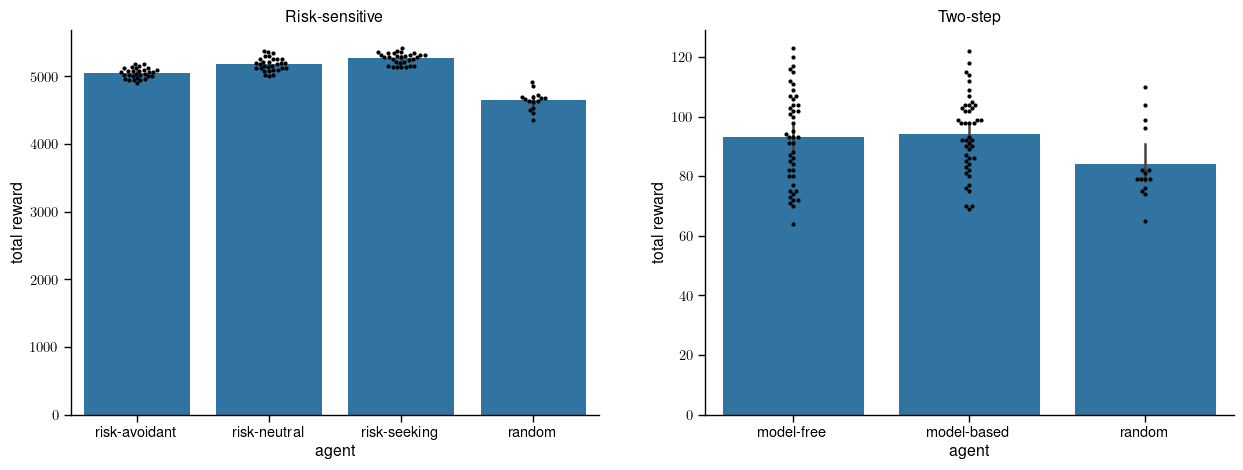

In [10]:
agent_df = pd.DataFrame(agent_data_sim)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes = axes.flatten()

sns.barplot(
    agent_df.query("task == 'risk-sensitive'"),
    x="agent_valence",
    y="reward",
    ax=axes[0],
)
sns.swarmplot(
    agent_df.query("task == 'risk-sensitive'"),
    x="agent_valence",
    size=3,
    color="black",
    y="reward",
    ax=axes[0],
)

sns.barplot(agent_df.query("task == 'two-step'"), x="agent_model", y="reward", ax=axes[1])
sns.swarmplot(
    agent_df.query("task == 'two-step'"),
    x="agent_model",
    size=3,
    y="reward",
    color="black",
    ax=axes[1],
)

titles = ["Risk-sensitive", "Two-step"]

for ii in range(2):
    axes[ii].spines["top"].set_visible(False)
    axes[ii].spines["right"].set_visible(False)
    axes[ii].set(ylabel="total reward", xlabel="agent", title=titles[ii])


plt.savefig(f"rl_simulation_performance{plot_format}", bbox_inches="tight", dpi=600)

# Parameter and model recovery

The simulated data were also subjected to model recovery and parameter recovery analyses. Here, we inverted six different models: a full model, where $\alpha^+$, $\alpha^-$, and $w$ were free parameters, a model-free classic Q-agent with fixed $w=0$ and a single free learning rate $\alpha$,  a model-based classic Q-agent with fixed $w=1$ and  as single $\alpha$, a model-free risk-sensitive Q-agent with fixed $w=0$, and free learning rates $\alpha^+$, and $\alpha^-$, a model-based risk-sensitive Q-agent with fixed $w=1$, and free $\alpha^+$, and $\alpha^-$, and a random agent, which has uniform probability over its available actions.

We optimized each agent on each of the simulated datasets, using `scipy.otimize.minimize` (Virtanen et al., 2020), using the Nelder-Mead algorithm. We set initial parameters of all free parameters to 0.5 and added bounds of $[0, 1]$.
Optimization was done using the negative log likelihood ($-\ln L$) which was defined as:
$$-\ln L = -\ln\sum_{t}P(s_t,a_t)$$

Parameters were thus selected as:

$$
\hat{\theta} = \arg\min_{\theta} \left( -\ln L(\theta; s_t, a_t, r_t, s_{t+1}, \text{avail actions}) \right)
$$

To account for local minima and other potential convergence issues, we restarted the optimization five times, selecting the outcome with the lowest negative log-likelihood. 

This model inference step highlights one of the strengths of our framework. Due to the standardized form of defining environments and how artificial agents interact with them, we can re-use the agent's code used for simulation also for model inference.
In the optimization procedure, we can loop over the collected data of each step ($s_{t}$, $a_{t}$, $s_{t+1}$, $r_t$, and available actions) and use the same implementation of the agent we used for simulation using the agent's `update` and `get_probs` methods. The `update` method, performs the updating step of the Q-values as described above. The `get_probs` method, returns the probabilities of the available actions via softmax, which we can use to calculate the log-likelihood. Because we can write each agent in this way, there is only a need to write optimization procedures once, reducing the need for specialized code. 

For model comparison, we calculate the Bayesian information criterion:
$$BIC = p * \ln n - 2 \ln L,$$
where $p$ is the number of free parameters and $n$ the number of steps (available data points). The random agent, in this case, does not have free parameters and thus reduces to $-2\ln L$. 

In [11]:
def loglikelihood_binary(x, *args):
    # Extract the arguments as they are passed by scipy.optimize.minimize
    (
        agent,
        parameter_names,
        agent_settings,
        actions,
        rewards,
        starting,
        obs,
        terminated,
        avail_actions,
    ) = args

    agent_settings.update({i: j for i, j in zip(parameter_names, x)})

    agent = agent(**agent_settings)

    # Initialize values
    logp_actions = np.zeros(len(actions))

    for t, (a, r, o, ot1, term, ava) in enumerate(zip(actions, rewards, starting, obs, terminated, avail_actions)):
        # Apply the softmax transformation
        logp_action = np.log(agent.get_probs(o, ava) + np.finfo(float).eps)

        logp_actions[t] = logp_action[a]
        agent.update(o, a, r, term, ot1)

    # Return the negative log likelihood of all observed actions
    return -np.sum(logp_actions[:])


def optimize_loglikelihood(
    actions: List,
    rewards: List,
    obs0: List,
    obs1: List,
    terminated: List,
    avail_actions: List,
    agent_settings: Dict,
    parameter_names: List,
    parameter_settings: Dict,
    agent,
    method: str = "Nelder-Mead",
):
    initial_params = [parameter_settings[i]["initial"] for i in parameter_names]
    bounds = tuple(parameter_settings[i]["bounds"] for i in parameter_names)

    result = scipy.optimize.minimize(
        loglikelihood_binary,
        initial_params,
        args=(
            agent,
            parameter_names,
            agent_settings,
            actions,
            rewards,
            obs0,
            obs1,
            terminated,
            avail_actions,
        ),
        method=method,
        bounds=bounds,
    )

    return result

### Helper functions to collect data and set up agents


In [12]:
recovery_df_fields = [
    "task",
    "set",
    "recov_agent",
    "alpha_mf_pos",
    "alpha_mf_neg",
    "alpha_mf",
    "hybrid",
    "lln",
    "bic",
    "orig_params",
    "orig_agent",
    "orig_agent_model",
    "orig_agent_valence",
    "recov_agent_model",
    "recov_agent_valence",
]


def return_data(idx, task, recov_agent, result, params_name, agent_data):

    recovery_data = {key: [] for key in recovery_df_fields}
    params_to_track = ["alpha_mf_pos", "alpha_mf_neg", "alpha_mf", "hybrid"]

    recovery_data["set"] = idx
    recovery_data["task"] = task
    recovery_data["recov_agent"] = recov_agent

    for pc, pn in enumerate(params_name):
        if pn in params_to_track:
            recovery_data[pn] = result.x[pc]

    for pn in set(params_to_track) - set(params_name):
        recovery_data[pn] = np.nan

    if recov_agent in ['random']:
        nopa = 0
    else: 
        nopa = len(params_name)
    
    ag_val, ag_model = safe_split(recov_agent)
    recovery_data["lln"] = result.fun
    recovery_data["bic"] = nopa * np.log(len(agent_data["actions"][idx])) + 2 * result.fun
    recovery_data["orig_params"] = agent_data["params"][idx]
    recovery_data["orig_agent"] = agent_data["agent"][idx]
    recovery_data["orig_agent_model"] = agent_data["agent_model"][idx]
    recovery_data["orig_agent_valence"] = agent_data["agent_valence"][idx]
    recovery_data["recov_agent_model"] = ag_model
    recovery_data["recov_agent_valence"] = ag_val

    return [recovery_data[rf] for rf in recovery_df_fields]

def create_agent(env, agent_val="valence", agent_model="model-based"):
    agent_fixed_params = {
        "alpha_mb": 0,
        "discount_factor": 1.0,
        "use_fixed": True,
        "temperature": 5.0,
        "state_space": env.n_states,
        "action_space": env.n_actions,
        "graph": env.full_graph,
    }

    if agent_val in ["valence", "full"]:
        agent = ValenceHybridAgent
        agent_free_param_names = ["alpha_mf_pos", "alpha_mf_neg"]
        agent_free_params = {
            "alpha_mf_pos": {"initial": 0.5, "bounds": [0, 1]},
            "alpha_mf_neg": {"initial": 0.5, "bounds": [0, 1]},
        }
    elif agent_val == "classic":
        agent_free_param_names = ["alpha_mf"]
        agent_free_params = {"alpha_mf": {"initial": 0.5, "bounds": [0, 1]}}
        agent = HybridAgent
    elif agent_val == "random" or agent_model == "random":
        agent = RandomAgent
        agent_free_param_names = ["dummy"]
        agent_free_params = {"dummy": {"initial": 0.5, "bounds": [0, 1]}}

    if agent_model == "model-based":
        agent_fixed_params["hybrid"] = 1.0
    elif agent_model == "model-free":
        agent_fixed_params["hybrid"] = 0.0
    elif agent_model == "full":
        agent_free_param_names += ["hybrid"]
        agent_free_params["hybrid"] = {"initial": 0.5, "bounds": [0, 1]}

    return agent, agent_fixed_params, agent_free_param_names, agent_free_params

## Optimization loop

In [13]:
recov_agent_names = [
    "valence_model-based",
    "valence_model-free",
    "classic_model-based",
    "classic_model-free",
    "full",
    "random",
]

def process_task(idx: int, task: str, agent_data_sim: Dict, recov_agent_names: str, recovery_data: Dict, n_restarts=5):
    """
    Helper function to do inference on a single agent.
    """
    env = get_env(task)
    recov_data = []

    for recov_agent in recov_agent_names:
        agent_val, agent_mod = safe_split(recov_agent)
        agent, agent_fixed_params, agent_free_param_names, agent_free_params = create_agent(env, agent_val=agent_val, agent_model=agent_mod)

        fun_threshold = np.inf
        
        for n in range(n_restarts):
            tmp_result = optimize_loglikelihood(
                agent_data_sim["actions"][idx],
                agent_data_sim["rewards"][idx],
                agent_data_sim["obs0"][idx],
                agent_data_sim["obs1"][idx],
                agent_data_sim["terminated"][idx],
                agent_data_sim["avail-actions"][idx],
                agent_settings=agent_fixed_params,
                parameter_names=agent_free_param_names,
                parameter_settings=agent_free_params,
                agent=agent,
            )

            if n == 0:
                result = tmp_result
            elif n > 0 and tmp_result.fun < result.fun:
                result = tmp_result
            

        recov_data.append(return_data(
            idx,
            task,
            recov_agent,
            result,
            agent_free_param_names,
            agent_data_sim,
        ))
    
    return recov_data


if not os.path.isfile("pm_recovery.npy") or REDO:
    # Initialize recovery data dictionary

    recovery_data = {key: [] for key in recovery_df_fields}

    if use_parallel:
        # Run the loop in parallel
        recovered = Parallel(n_jobs=-1)(
            delayed(process_task)(idx, task, agent_data_sim, recov_agent_names, recovery_data)
            for idx, task in tqdm(
                enumerate(agent_data_sim["task"]),
                total=len(agent_data_sim["task"]),
                desc="Inferring task data",
            )
        )
        # Additionally flatten output
        recovered2 = []
        for sublist in recovered:
            recovered2.extend(sublist)
        recovered = recovered2
    else:
        # Main loop
        for idx, task in tqdm(
            enumerate(agent_data_sim["task"]),
            total=len(agent_data_sim["task"]),
            desc="Inferring task data",
        ):
            env = get_env(task)
            recovered.extend(process_task(idx=idx, task=task, agent_data_sim=agent_data_sim, recov_agent_names=recov_agent_names,
                                recovery_data=recovery_data))

    for re in recovered:
        for rf, rd in zip(recovery_df_fields, re):
            recovery_data[rf].append(rd)

    np.save("pm_recovery", recovery_data)
else:
    recovery_data = np.load("pm_recovery.npy", allow_pickle=True).item()

In [14]:
recov_data = pd.DataFrame(recovery_data)

task_recov_rs = recov_data.query(
    "task=='risk-sensitive' and orig_agent_valence in ['risk-avoidant', 'risk-neutral', 'risk-seeking'] and recov_agent_valence == 'full'"
)
original_learning_rate_pos = [task_recov_rs.iloc[i, :]["orig_params"][1] for i in range(task_recov_rs.shape[0])]
original_learning_rate_neg = [task_recov_rs.iloc[i, :]["orig_params"][0] for i in range(task_recov_rs.shape[0])]


task_recov_ts = recov_data.query(
    "task=='two-step' and orig_agent_valence in ['risk-avoidant', 'risk-neutral', 'risk-seeking'] and recov_agent_valence == 'full'"
)
original_hybrid = [task_recov_ts.iloc[i, :]["orig_params"][2] for i in range(task_recov_ts.shape[0])]

In [15]:
def calc_conf_matrix(recov_data, task, agent_orig, agent_recov, normalize=True):
    recov_data_by_set = (
        recov_data.query("task==@task and 'full' not in recov_agent_model")
        .groupby([agent_orig, agent_recov, "set"])[["bic", "lln"]]
        .mean()
        .reset_index()
    )
    min_bic_df_idx = recov_data_by_set.groupby("set")["bic"].idxmin()
    min_bic_df = recov_data_by_set.loc[min_bic_df_idx]
    classes = min_bic_df[agent_orig].unique()
    recovs = min_bic_df[agent_recov].unique()

    conf_matrix = pd.DataFrame(0, index=recovs, columns=classes)

    # Populate the confusion matrix
    for orig, recov in zip(min_bic_df[agent_orig], min_bic_df[agent_recov]):
        conf_matrix.loc[recov, orig] += 1

    if normalize:
        conf_matrix = conf_matrix / conf_matrix.sum(0)

    return conf_matrix

## Recovery results
As in the benchmarking step, we collapsed the model comparison step over model-free and model-based agents in the risk-sensitive task and over risk behavior in the two-step task. We see that in both tasks, the generative model class of interest can be recovered, by selecting the agent with the lowest $BIC$.

We further tested if the full agent could accurately recover parameters of interest in the risk-sensitive ($\alpha^+, \alpha^-$) and in the two-step tasks ($w$) we see that the recovered parameters are highly correlated with the original parameters.


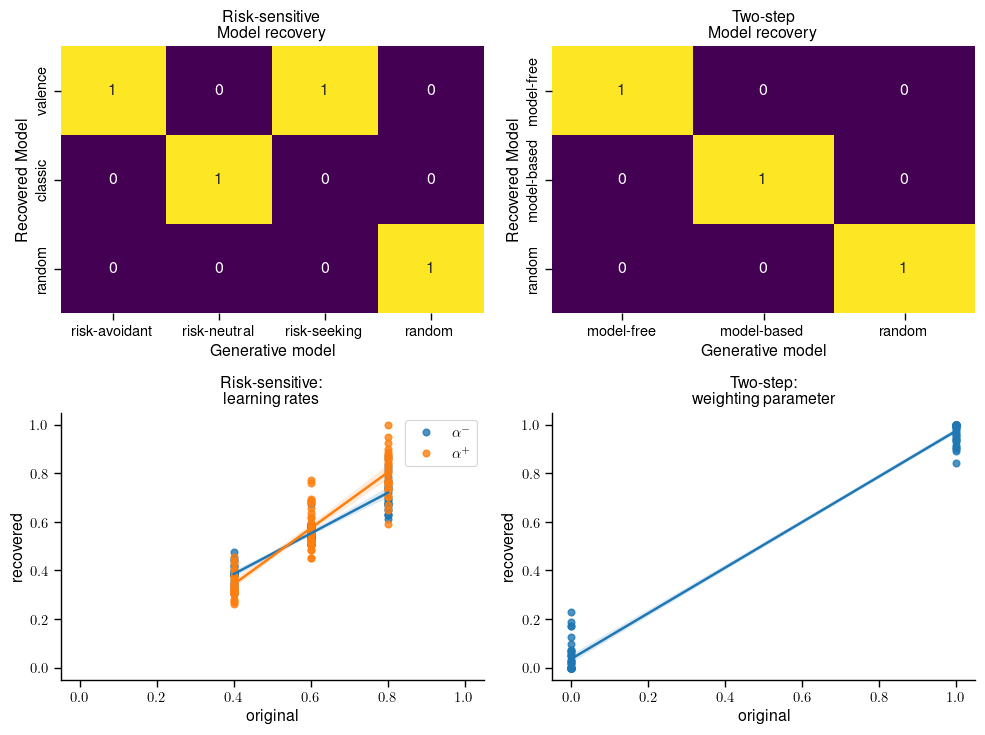

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7.5))

axes = axes.flatten()

sns.regplot(
    x=original_learning_rate_neg,
    y=task_recov_rs.alpha_mf_neg,
    ax=axes[2],
    label=r"$\alpha^-$",
)
sns.regplot(
    x=original_learning_rate_pos,
    y=task_recov_rs.alpha_mf_pos,
    ax=axes[2],
    label=r"$\alpha^+$",
)

sns.regplot(x=original_hybrid, y=task_recov_ts.hybrid, ax=axes[3])

titles = [
    "Risk-sensitive\nModel recovery",
    "Two-step\nModel recovery",
    "Risk-sensitive:\nlearning rates",
    "Two-step:\nweighting parameter",
]
for ii in range(2, 4):
    axes[ii].spines["top"].set_visible(False)
    axes[ii].spines["right"].set_visible(False)
    axes[ii].set(
        xlabel="original",
        ylabel="recovered",
        title=titles[ii],
        xlim=[-0.05, 1.05],
        ylim=[-0.05, 1.05],
    )

    if ii == 2:
        axes[ii].legend()


sns.heatmap(
    calc_conf_matrix(recov_data, "risk-sensitive", "orig_agent_valence", "recov_agent_valence"),
    annot=True,
    cmap="viridis",
    cbar=False,
    ax=axes[0],
)
sns.heatmap(
    calc_conf_matrix(recov_data, "two-step", "orig_agent_model", "recov_agent_model"),
    annot=True,
    cmap="viridis",
    cbar=False,
    ax=axes[1],
)

for ii in range(0, 2):
    axes[ii].set(
        title=titles[ii],
        xlabel="Generative model",
        ylabel="Recovered Model",
    )

plt.tight_layout()

plt.savefig(f"rl_recovery{plot_format}", bbox_inches="tight", dpi=600)

# Behavioral Simulation
We further investigate if the agents show the expected behavioral patterns that are predicted by the respective computational theories.
In the risk-sensitive task, we see how the proportion of safe choices is related to the balance of positive and negative learning rates as predicted by the model (Niv et al. 2012; Rosenbaum et al. 2022)  In the two-step task, agents following model-based strategies are more likely to repeat the previous first-level choice after expected and rewarded, as well as unexpected and not rewarded transitions. The model-free agents in contrast will stick to the rewarded choice, independent of the transition (Decker et al. 2016) . 

In [18]:
random_state = np.random.default_rng(2025)

simulation_data_core = [
    "task",
    "agent",
    "reward",
    "params",
    "agent_model",
    "agent_valence",
]
simulation_data_behav = ["dataframes"]

if not os.path.isfile("behavioral_simulation.npy") or REDO:
    agent_data = {i: [] for i in simulation_data_core + simulation_data_behav}

    for task in tasks:
        for n in range(n_agents):
            env = get_env(task)

            agent_names = []
            agents = []
            params = []

            for lrp, lrn, valn in zip(alpha_mf_pos, alpha_mf_neg, valence_names):
                for we, wen in zip(mb_mf_weighting, model_names):
                    agents.append(
                        ValenceHybridAgent(
                            alpha_mf_neg=lrn,
                            alpha_mf_pos=lrp,
                            alpha_mb=alpha_forward,
                            temperature=temperature,
                            discount_factor=discounting,
                            state_space=env.n_states,
                            hybrid=we,
                            graph=env.full_graph,
                            use_fixed=True,
                            eligiblity_decay=1.0,
                            action_space=env.n_actions,
                            random_state=random_state,
                        )
                    )

                    agent_names.append(f"{valn}_{wen}")
                    params.append((lrn, lrp, we))

            ragents = [
                RandomAgent(
                    action_space=env.n_actions,
                    state_space=env.n_states,
                    seed=random_state,
                )
            ]

            for ag, agn, par in zip(agents + ragents, agent_names + ragents_names, params + [None]):
                env = get_env(task, seed=random_state, render_backend="psychopy-simulate")
                simlog = SimulationLogger(file_name="blank", task=task, participant_id=n)
                simlog.create()
                env.setup(logger=simlog, window=None, expose_last_stim=True)
                df, _, _ = pspy_run_task(env, logger=simlog, agent=ag, seed=n)
                agent_data["task"].append(task)
                agent_data["agent"].append(agn)
                agent_data["agent_model"].append(agn.split("_")[1] if agn != "random" else "random")
                agent_data["agent_valence"].append(agn.split("_")[0] if agn != "random" else "random")
                agent_data["dataframes"].append(pd.DataFrame(df.close()))

    np.save("behavioral_simulation", agent_data)
else:
    agent_data = np.load("behavioral_simulation.npy", allow_pickle=True).item()

### Behavioral analyses helper functions

In [19]:
def add_additional_columns(df, new_col_name=[], new_col_value=[]):
    for ncn, ncv in zip(new_col_name, new_col_value):
        df[ncn] = ncv

    return df


def process_responses(data, query_filter, group_by_cols, value_col):
    return data.query(query_filter).groupby(group_by_cols).size().reset_index(name=value_col)


def add_risk_sensitive_meaning(data, response_left=0, response_right=1):
    def string_to_ev(part):
        if "null" in part:
            return 0, "null"

        mod, val = part.split("-")
        val_mod = 1 if mod == "save" else 0.5

        return float(val) * val_mod, mod

    response_events = data.eval("event_type == 'response'")
    data["save_or_correct"] = np.nan
    data["correct_response"] = np.nan
    data["trial_classification"] = ""

    save_answers = []
    trial_categories = []

    for ii in data.loc[response_events, "trial_type"].values:
        tmp1, tmp2 = ii.split("_")

        trial_category, save_answer = None, None
        if "none" in tmp1 or "none" in tmp2:
            trial_category = "forced"
            save_answer = response_right if "none" in tmp1 else response_left
        elif tmp1 == "risky-80" and tmp2 == "save-20":
            trial_category = "risky"
            save_answer = response_right
        elif tmp1 == "save-20" and tmp2 == "risky-80":
            trial_category = "risky"
            save_answer = response_left
        else:
            ev1, m1 = string_to_ev(tmp1)
            ev2, m2 = string_to_ev(tmp2)

            if ev1 == ev2:
                trial_category = "risky"
                save_answer = response_left if m1 == "save" else response_right
            else:
                trial_category = "test"
                save_answer = response_left if ev1 > ev2 else response_right

        save_answers.append(save_answer)
        trial_categories.append(trial_category)

    data.loc[response_events, "save_or_correct"] = np.array(save_answers)
    data.loc[response_events, "trial_classification"] = np.array(trial_categories)

    data["trial_classification"] = data["trial_classification"].replace("", np.nan)
    data["trial_classification"] = (
        data.groupby("trial")["trial_classification"]
        .transform(lambda group: group.ffill().bfill())
    )

    data.loc[response_events, "correct_response"] = (
        data.loc[response_events, "response_button"].astype(float) == data.loc[response_events, "save_or_correct"].astype(float)
    ) * 1.0

    return data


def summary_df_risk_sensitive(risk_data, participant):
    # Extracting mean correct responses (proportions)
    correct_responses = (
        risk_data.query("event_type=='response'")
        .groupby("trial_classification")
        .correct_response.mean()
        .reset_index()
        .rename(columns={"correct_response": "value"})
    )

    total_reward = risk_data.query("event_type == 'trial-end'").total_reward.values[-1]

    count_responses = add_additional_columns(correct_responses, ["metric"], ["proportion"])

    # Extracting counts of correct responses
    count_responses = process_responses(
        data=risk_data,
        query_filter="event_type=='response'",
        group_by_cols=["trial_classification", "correct_response"],
        value_col="value",
    )
    count_responses = add_additional_columns(count_responses, ["metric"], ["count"])

    # Combine everything into a long-format dataframe
    long_format_df = pd.concat(
        [
            correct_responses.assign(participant=participant, total_reward=total_reward),
            count_responses.assign(participant=participant, total_reward=total_reward),
        ],
        ignore_index=True,
    )

    return long_format_df


def add_twostep_meaning(data):
    matching_dict = {
        "1-2": "expected",
        "0-1": "expected",
        "1-1": "unexpected",
        "0-2": "unexpected",
    }
    reward_meaning = {0: "no-reward", 1: "reward"}

    new_columns = [
        "stay",
        "transition",
        "transition_reward",
        "rewarded",
        "previous_rewarded",
    ]
    for fill_col in new_columns:
        data[fill_col] = ""

    stage1 = data.eval("event_type=='stage-1-selection'")

    data["trial"] = data["trial"].astype(int)
    first_response = data.loc[
        data.query('event_type == "response"').groupby("trial")["action"].idxmin(),
        "action",
    ].values.astype(int)
    reward = data.query("event_type == 'trial-end'").reward.values.astype(int)

    transition = data.query("event_type=='stage-2-selection'").current_location.values.astype(int)

    transition = [matching_dict[i + "-" + j] for i, j in zip(first_response.astype(str), transition.astype(str))]

    stay = [np.nan] + [i == j for i, j in zip(first_response[:-1], first_response[1:])]

    transition_reward = [reward_meaning[r] + "_" + j for r, j in zip(reward, transition)]
    rewarded = [reward_meaning[r] for r in reward]

    data.loc[stage1, "stay"] = stay
    data.loc[stage1, "transition"] = transition
    data.loc[stage1, "transition_reward"] = [np.nan] + transition_reward[:-1]
    data.loc[stage1, "rewarded"] = rewarded
    data.loc[stage1, "previous_rewarded"] = [np.nan] + rewarded[:-1]

    for fill_col in new_columns:
        data[fill_col] = data[fill_col].replace("", np.nan)
        data[fill_col] = data.groupby("trial")[fill_col].transform(lambda group: group.ffill().bfill())

    return data


def summary_twostep_df(data, participant):
    data.loc[:, "stay"] = data.loc[:, "stay"].astype(float)

    temp_df = data.groupby(["transition_reward"]).stay.mean().reset_index().rename(columns={"transition_reward": "trial_type", "stay": "value"})
    temp_df = add_additional_columns(temp_df, ["metric"], ["proportion"])

    total_reward = data.query("event_type == 'trial-end'").total_reward.values[-1]

    # Combine everything into a long-format dataframe
    long_format_df = pd.concat(
        [
            temp_df.assign(participant=participant, total_reward=total_reward),
        ],
        ignore_index=True,
    )

    return long_format_df

In [20]:
summary_dfs = {ii: [] for ii in ["risk-sensitive", "two-step"]}

for n, (df, task, ag, agm, agv) in enumerate(
    zip(
        agent_data["dataframes"],
        agent_data["task"],
        agent_data["agent"],
        agent_data["agent_model"],
        agent_data["agent_valence"],
    )
):
    if task == "risk-sensitive":
        rs_men = add_risk_sensitive_meaning(df)
        sum_df = summary_df_risk_sensitive(rs_men, ag + f"_{n}")

    elif task == "two-step":
        ts_men = add_twostep_meaning(df)
        sum_df = summary_twostep_df(ts_men, ag + f"_{n}")

    sum_df["agent_valence"] = agv
    sum_df["agent_model"] = agm

    summary_dfs[task].append(sum_df)


rs_df_cc = pd.concat(summary_dfs["risk-sensitive"], ignore_index=False)
ts_df_cc = pd.concat(summary_dfs["two-step"], ignore_index=False)

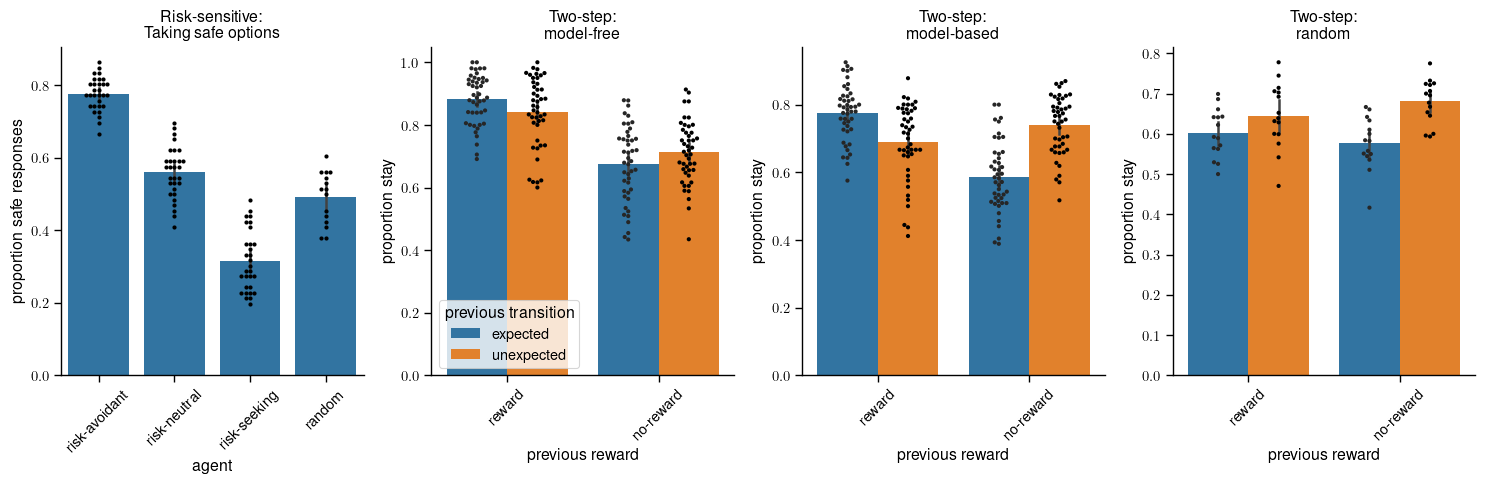

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

horder = ["expected", "unexpected"]
xorder = ["reward", "no-reward"]
ts_models = ["Two-step:\nmodel-free", "Two-step:\nmodel-based", "Two-step:\nrandom"]

rs_df_cc = pd.concat(summary_dfs["risk-sensitive"], ignore_index=False)
ts_df_cc = pd.concat(summary_dfs["two-step"], ignore_index=False)

plot_df = ts_df_cc.query("metric == 'proportion'")
plot_df.loc[:, ["reward", "transition"]] = plot_df.trial_type.str.split("_", expand=True).values


sns.barplot(
    plot_df.query("agent_model=='model-free'"),
    x="reward",
    hue="transition",
    order=xorder,
    hue_order=horder,
    y="value",
    ax=axes[1],
)
sns.swarmplot(
    plot_df.query("agent_model=='model-free'"),
    x="reward",
    hue="transition",
    order=xorder,
    hue_order=horder,
    y="value",
    size=3,
    palette="dark:black",
    dodge=True,
    ax=axes[1],
    legend=False,
)

sns.barplot(
    plot_df.query("agent_model=='model-based'"),
    x="reward",
    hue="transition",
    order=xorder,
    hue_order=horder,
    y="value",
    ax=axes[2],
)
sns.swarmplot(
    plot_df.query("agent_model=='model-based'"),
    size=3,
    x="reward",
    hue="transition",
    order=xorder,
    hue_order=horder,
    y="value",
    palette="dark:black",
    dodge=True,
    ax=axes[2],
)

sns.barplot(
    plot_df.query("agent_model=='random'"),
    x="reward",
    hue="transition",
    order=xorder,
    hue_order=horder,
    y="value",
    ax=axes[3],
)
sns.swarmplot(
    plot_df.query("agent_model=='random'"),
    size=3,
    x="reward",
    hue="transition",
    order=xorder,
    hue_order=horder,
    y="value",
    palette="dark:black",
    dodge=True,
    ax=axes[3],
)

sns.barplot(
    rs_df_cc.query("metric=='proportion' and trial_classification=='risky'"),
    x="agent_valence",
    y="value",
    ax=axes[0],
)
sns.swarmplot(
    rs_df_cc.query("metric=='proportion' and trial_classification=='risky'"),
    x="agent_valence",
    y="value",
    dodge=True,
    color="black",
    ax=axes[0],
    size=3,
    label=None,
)

for ii in range(4):
    if ii in [1, 2, 3]:
        axes[ii].set(
            ylabel="proportion stay",
            title=ts_models[ii - 1],
            xlabel="previous reward",
        )
    axes[ii].spines["top"].set_visible(False)
    axes[ii].spines["right"].set_visible(False)
    axes[ii].tick_params(axis="x", labelrotation=45)
    if ii in [2, 3]:
        axes[ii].legend().set_visible(False)
    elif ii == 1:
        axes[ii].legend(title="previous transition")

    if ii == 0:
        axes[ii].set(
            ylabel="proportion safe responses",
            title="Risk-sensitive:\nTaking safe options",
            xlabel="agent",
        )

plt.tight_layout()
plt.savefig(f"behavioral_simulation{plot_format}", bbox_inches="tight", dpi=600)